# Analysis
This notebook includes analysis pipelines to examine the accuracy of the synthetic trials

In [ ]:
import sys
sys.path.append('../src/pinn')
sys.path.append('../src/data_generation')

In [11]:
# create dictionary
# the calculation is based on Mem3DG pulg-in functions
# notebook: Mem3DG/tests/python/pinn_synthetic/calc_mesh_properties.ipynb

area_mem = {
    "biconcave": 4.509775652390608,
    # "bud":       4.767351221422792, # for margin_ratio = -0.2
    # "bud": 4.79, # test
    # "bud":       8.475291060307185,
    "bud_04":       5.187943386967171,  # for margin_ratio = -0.4
    "multi":      5.257892208208614 + 0.8607915589346745
}

bend_mem = {
    "biconcave": 34.23409861449123,
    "bud":       21.941595635908413,
    "bud_04":       21.941595635908413,
    "multi":     30.912018724759164 + 25.420889021757755
}

In [3]:
# Dice Loss (single calculation)
from pinn.analysis import dice_loss
from flax.training import checkpoints
import os

# parameters
grid_size = 64
lambda_1 = 1000000
lambda_2 = 0
step = 10000
epsilon = 0.05
# shape = "biconcave"
shape = "bud"

# import data
ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/clean/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
mrc_path = f"../data/synthetic/{shape}.mrc"

loss = dice_loss(mrc_path, dat_seg, grid_size=grid_size, threshold=0.8, band_thickness=0.2)
print("Dice loss:", loss)


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  3890
gt:  4773
pd:  4553
volume_sum:  9326
Dice loss: 0.1657731


Resizing MRC data from (128, 128, 128) to (64, 64, 64)
(64, 64, 64)
(64, 64, 64)


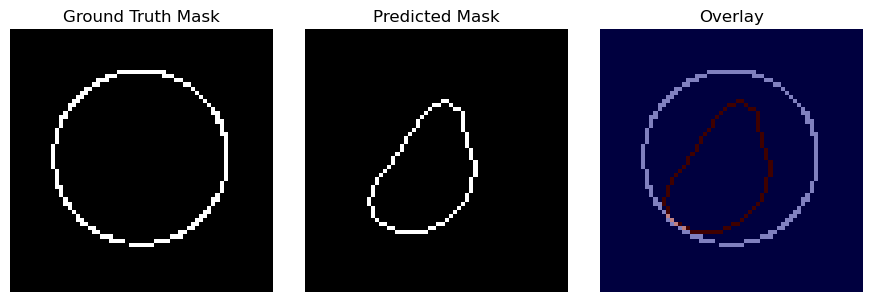

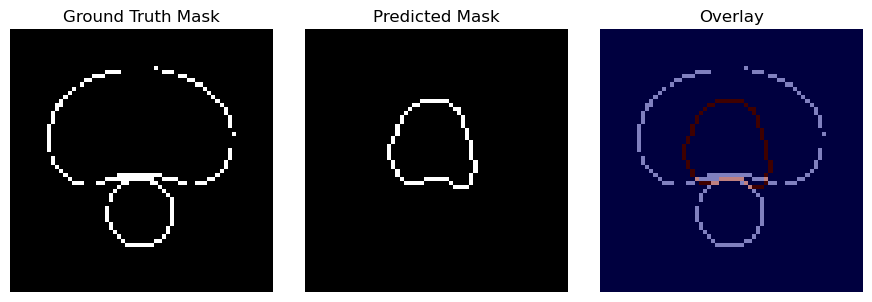

In [8]:
# Visualize masks

import matplotlib.pyplot as plt
import numpy as np
import os
from flax.training import checkpoints
from pinn.analysis import dice_loss, get_masks, visualize_masks

# parameters
lambda_1 = 1000000
lambda_2 = 1000
step = 10000
epsilon = 0.05
# shape = "biconcave"
shape = "multi"

# import data
ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/clean/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
mrc_path = f"../data/synthetic/{shape}.mrc"

# loss = dice_loss(mrc_path, dat_seg, grid_size=grid_size, threshold=threshold, )
gt_mask, pred_mask = get_masks(mrc_path, dat_seg, grid_size=64, threshold=0.8, band_thickness=0.2)

print(gt_mask.shape)
print(pred_mask.shape)

# visualize
visualize_masks(gt_mask, pred_mask, axis=0)  # z-slice
visualize_masks(gt_mask, pred_mask, axis=1)  # y-slice
# visualize_masks(gt_mask, pred_mask, axis=2)  # x-slice


In [ ]:
# Area and Energy (indivisual calculation)

import os
import numpy as np
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.analysis import calc_area_mem, calc_bend_mem
from pinn.analysis import calc_area_seg, calc_bend_seg

# parameters
GRID_SIZE = 64
lambda_1 = 1000000
lambda_2 = 100
step = 10000
epsilon = 0.05
kappa = 1
# shape = "biconcave"
shape = "bud"
# shape = "multi"

# import data
ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/clean/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
mrc_path = f"../data/synthetic/{shape}.mrc"

area_mrc = calc_area_mem(mrc_path, iso_value=0.8)
area_seg = calc_area_seg(dat_seg, epsilon=epsilon, sampling="random", num_point=10000)
print("Area: ", area_mem[shape], area_seg, np.abs(area_mem[shape] - area_seg)/area_mem[shape])
print("Area: ", area_mrc, area_seg, np.abs(area_mrc - area_seg)/area_mrc)

# bend_mrc = calc_bend_mem(mrc_path, iso_value=0.8)
bend_seg = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=10000)
print("Bend: ", bend_mem[shape], bend_seg, np.abs(bend_mem[shape] - bend_seg)/bend_mem[shape])
# print(bend_mrc, bend_seg, np.abs(bend_mrc - bend_seg)/bend_mrc)


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Area:  4.767351221422792 4.797454 0.006314351177251688
Area:  4.298568608009244 4.797454 0.11605843717245334
Bend:  21.941595635908413 15.531735 0.2921327948819535


Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  4717
gt:  6019
pd:  4915
volume_sum:  10934
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  4724
gt:  6019
pd:  4919
volume_sum:  10938
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  4707
gt:  6019
pd:  4926
volume_sum:  10945
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  597
gt:  6019
pd:  1566
volume_sum:  7585


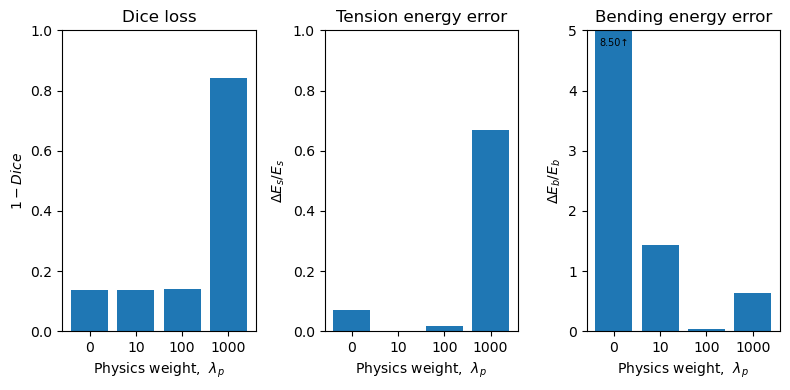

In [ ]:
# Dice, Area and Energy (comparison using bar graph)

import os
import numpy as np
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.analysis import calc_area_seg, calc_bend_seg, dice_loss
import matplotlib.pyplot as plt

from pinn.analysis import calc_area_mem, calc_bend_mem
from pinn.analysis import calc_area_seg, calc_bend_seg

# parameters
lambda_1 = 1000000
lambda_2_list = [0, 10, 100, 1000]
step = 10000
epsilon = 0.05
kappa = 1
# shape = "biconcave"
shape = "bud_04"
# shape = "multi"

dice_los_dict = {}
area_seg_dict = {}
bend_seg_dict = {}


# calculation of the surface area based on MRC
mrc_path = f"../data/synthetic/{shape}.mrc"
area_mrc = calc_area_mem(mrc_path, iso_value=0.8)


for lambda_2 in lambda_2_list:

    # import data
    ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/clean/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
    dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
    mrc_path = f"../data/synthetic/{shape}.mrc"

    dice_los = dice_loss(mrc_path, dat_seg, grid_size=64, threshold=0.8, band_thickness=0.2)
    area_seg = calc_area_seg(dat_seg, epsilon=epsilon, sampling="random", num_point=10000)
    bend_seg = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=10000)

    dice_los_dict[lambda_2] = dice_los
    area_seg_dict[lambda_2] = np.abs(area_mem[shape] - area_seg) / area_mem[shape]
    # area_seg_dict[lambda_2] = np.abs(area_mrc - area_seg) / area_mem[shape]
    bend_seg_dict[lambda_2] = np.abs(bend_mem[shape] - bend_seg) / bend_mem[shape]




# Extract keys and values
labels = list(area_seg_dict.keys())
dice_losses = [float(dice_los_dict[k]) for k in labels]
area_values = [float(area_seg_dict[k]) for k in labels]
bend_values = [float(bend_seg_dict[k]) for k in labels]
x_pos = range(len(labels))

# Create two subplots side by side
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(8, 4), sharex=True)

# plot 0: dice loss
ax0.bar(x_pos, dice_losses)
ax0.set_xticks(x_pos)
ax0.set_xticklabels(labels)
ax0.set_xlabel(r"Physics weight,  $\lambda_p$")
ax0.set_ylabel(r"$1 - Dice$")
ax0.set_title(r"Dice loss")
ax0.set_ylim(0, 1)

# plot 1: area
ax1.bar(x_pos, area_values)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels)
ax1.set_xlabel(r"Physics weight,  $\lambda_p$")
# ax1.set_ylabel(r"$\Delta A / A$")
# ax1.set_title(r"Surface area error")
ax1.set_ylabel(r"$\Delta E_s / E_s$")
ax1.set_title(r"Tension energy error")
ax1.set_ylim(0, 1)

# plot2: bending
ax2.bar(x_pos, bend_values)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels)
ax2.set_xlabel(r"Physics weight,  $\lambda_p$")
ax2.set_ylabel(r"$\Delta E_b / E_b$")
ax2.set_title(r"Bending energy error")
ax2.set_ylim(0, 5)

# annotate outliers automatically
for xpos, val in zip(x_pos, bend_values):
    if val > 5:  # exceeds ylim
        ax2.text(xpos, 4.7, f"{val:.2f}↑", ha="center", va="bottom", fontsize=7)


plt.tight_layout()
plt.show()


/gscratch/matsulab/envs/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  3935
gt:  5267
pd:  3946
volume_sum:  9213
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  3941
gt:  5267
pd:  3944
volume_sum:  9211
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  3933
gt:  5267
pd:  3945
volume_sum:  9212
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  3693
gt:  5267
pd:  3998
volume_sum:  9265
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  4717
gt:  6019
pd:  4915
volume_sum:  10934
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  4724
gt:  6019
pd:  4919
volume_sum:  10938
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  4707
gt:  6019
pd:  4926
volume_sum:  10945
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  597
gt:  6019
pd:  1566
volume_sum:  7585
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
intersection:  4184
gt:  5059
pd:  5098

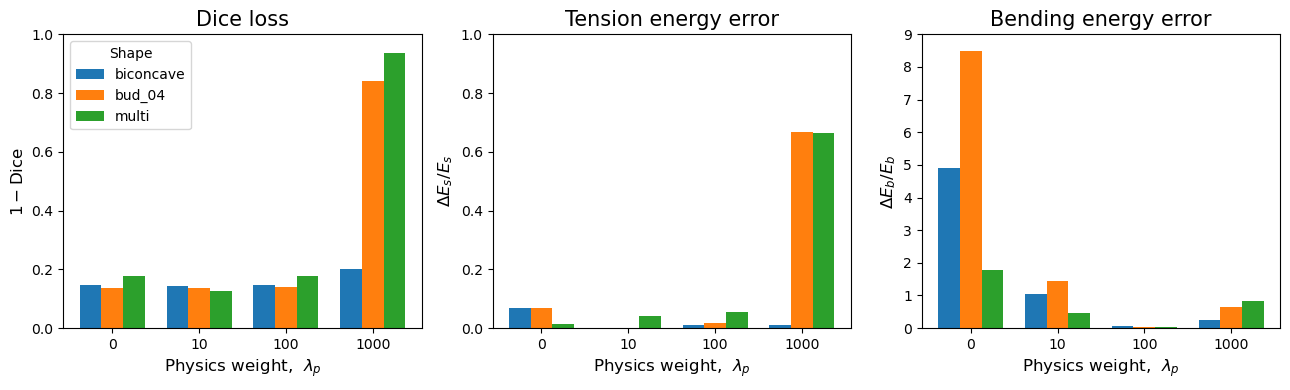

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# -------------------
# Parameters
# -------------------
lambda_1 = 1_000_000
lambda_2_list = [0, 10, 100, 1000]
step = 10000
epsilon = 0.05
kappa = 1.0
shapes = ["biconcave", "bud_04", "multi"]

# -------------------
# Storage
# -------------------
results = {key: {s: {} for s in shapes} for key in ["dice", "area_err", "bend_err"]}

# -------------------
# Main loop
# -------------------
for shape in shapes:
    # Ground truth from MRC
    mrc_path = f"../data/synthetic/{shape}.mrc"
    # area_true = calc_area_mem(mrc_path, iso_value=0.8)
    area_true = area_mem[shape]
    bend_true = bend_mem[shape]

    for lam2 in lambda_2_list:
        ckpt_dir = os.path.abspath(
            f"../outputs/logs/{shape}/clean/lambda_{lambda_1}_{lam2}/checkpoint_{step}"
        )
        dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

        dice_val = dice_loss(mrc_path, dat_seg, grid_size=64, threshold=0.8, band_thickness=0.2)
        area_seg_val = calc_area_seg(dat_seg, epsilon=epsilon, sampling="random", num_point=10000)
        bend_seg_val = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=10000)

        results["dice"][shape][lam2] = float(dice_val)
        results["area_err"][shape][lam2] = float(abs(area_true - area_seg_val) / area_true)
        results["bend_err"][shape][lam2] = float(abs(bend_true - bend_seg_val) / bend_true)

# -------------------
# Plotting: x-axis = λ₂, colors = shapes
# -------------------
metrics = [
    ("dice", r"$1 - \mathrm{Dice}$", "Dice loss"),
    # ("area_err", r"$\Delta A / A$", "Surface area error"),
    ("area_err", r"$\Delta E_s / E_s$", "Tension energy error"),    
    ("bend_err", r"$\Delta E_b / E_b$", "Bending energy error"),
]

x = np.arange(len(lambda_2_list))  # positions: [0,1,2,3]
w = 0.25                           # bar width

fig, axes = plt.subplots(1, len(metrics), figsize=(13, 4), sharey=False)

for ax, (key, ylab, title) in zip(axes, metrics):
    for i, shape in enumerate(shapes):
        vals = [results[key][shape][lam2] for lam2 in lambda_2_list]
        ax.bar(x + (i - (len(shapes)-1)/2)*w, vals, width=w, label=shape)

    ax.set_xticks(x)
    ax.set_xticklabels(lambda_2_list)
    ax.set_xlabel(r"Physics weight,  $\lambda_p$", fontsize=12)
    ax.set_ylabel(ylab, fontsize=12)
    ax.set_title(title, fontsize=15)

    if key == "dice":
        ax.set_ylim(0, 1.0)
    elif key == "area_err":
        # ax.set_ylim(0, 0.1)
        ax.set_ylim(0, 1)
    elif key == "bend_err":
        ax.set_ylim(0, 9)
    
        # # annotate outlier (lam2 = 0, shape="bud")
        # for i, shape in enumerate(shapes):
        #     val = results[key][shape][0]   # lam2 = 0
        #     if val > 5:  # outside ylim
        #         xpos = x[0] + (i - (len(shapes)-1)/2)*w  # bar position
        #         ax.text(xpos, 4.3, f"{val:.2f}↑", ha="center", va="bottom", fontsize=8, rotation=90)



axes[0].legend(title="Shape")

plt.tight_layout()
plt.show()


In [8]:
# Visualize the surface extracted from an MRC file using marching cubes.
# Ensure that the chosen iso_value produces a surface where the membrane 
# is thin enough to be treated as a doubled membrane.

import trimesh
import mrcfile
from skimage import measure
import trimesh

shape = "biconcave"
mrc_path = f"../data/synthetic/{shape}.mrc"
iso_value = 0.8

with mrcfile.open(mrc_path) as mrc:
    volume = mrc.data.astype(np.float32)
nx, ny, nz = volume.shape

# Choose iso-value
if iso_value is None:
    iso_value = float(np.mean(volume))

# Marching cubes in voxel space
verts, faces, normals, values = measure.marching_cubes(volume, level=iso_value)

# Rescale vertices to [-1,1]^3
verts[:, 0] = 2.0 * verts[:, 0] / nx - 1.0
verts[:, 1] = 2.0 * verts[:, 1] / ny - 1.0
verts[:, 2] = 2.0 * verts[:, 2] / nz - 1.0

# Mesh & surface area
mesh = trimesh.Trimesh(vertices=verts, faces=faces, process=False)
mesh.show()
